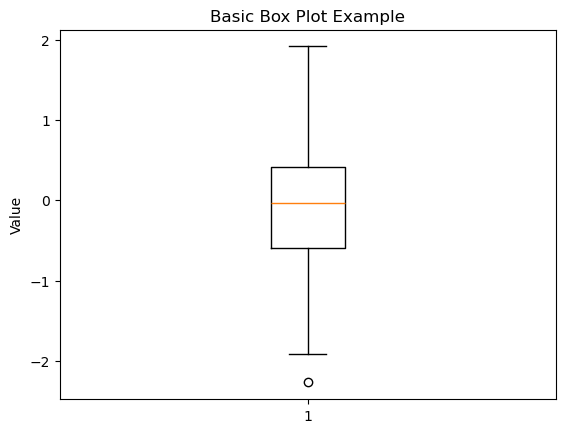

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Generate some sample data
data = np.random.normal(loc=0, scale=1, size=100) # Normally distributed data

# Create the box plot
plt.boxplot(data)

# Add labels and title
plt.title("Basic Box Plot Example")
plt.ylabel("Value")

# Display the plot
plt.show()

In [2]:
np.linalg.inv(np.eye(5)/2)

array([[2., 0., 0., 0., 0.],
       [0., 2., 0., 0., 0.],
       [0., 0., 2., 0., 0.],
       [0., 0., 0., 2., 0.],
       [0., 0., 0., 0., 2.]])

# pd.merge_asof

In [3]:
import pandas as pd

# Create sample DataFrames
df_left = pd.DataFrame({
    'time': pd.to_datetime(['2023-01-01 10:00', '2023-01-01 10:05', '2023-01-01 10:12', '2025-01-01 11:00']),
    'value_left': [10, 20, 30, 50]
})

df_right = pd.DataFrame({
    'time': pd.to_datetime(['2023-01-01 09:58', '2023-01-01 10:03', '2023-01-01 10:10', '2023-01-01 10:15']),
    'value_right': [100, 200, 300, 400]
})

# Perform a backward rolling join
result = pd.merge_asof(df_left, df_right, on='time', direction='backward', tolerance=pd.Timedelta(days=1))

print(result)

                 time  value_left  value_right
0 2023-01-01 10:00:00          10        100.0
1 2023-01-01 10:05:00          20        200.0
2 2023-01-01 10:12:00          30        300.0
3 2025-01-01 11:00:00          50          NaN


In [4]:
quotes = pd.DataFrame(
     {
         "time": [
             pd.Timestamp("2016-05-25 13:30:00.023"),
             pd.Timestamp("2016-05-25 13:30:00.023"),
             pd.Timestamp("2016-05-25 13:30:00.030"),
             pd.Timestamp("2016-05-25 13:30:00.041"),
             pd.Timestamp("2016-05-25 13:30:00.048"),
             pd.Timestamp("2016-05-25 13:30:00.049"),
             pd.Timestamp("2016-05-25 13:30:00.072"),
             pd.Timestamp("2016-05-25 13:30:00.075")
         ],
         "ticker": [
                "GOOG",
                "MSFT",
                "MSFT",
                "MSFT",
                "GOOG",
                "AAPL",
                "GOOG",
                "MSFT"
            ],
            "bid": [720.50, 51.95, 51.97, 51.99, 720.50, 97.99, 720.50, 52.01],
            "ask": [720.93, 51.96, 51.98, 52.00, 720.93, 98.01, 720.88, 52.03]
     }
)

In [5]:
trades = pd.DataFrame(
        {
            "time": [
                pd.Timestamp("2016-05-25 13:30:00.023"),
                pd.Timestamp("2016-05-25 13:30:00.038"),
                pd.Timestamp("2016-05-25 13:30:00.048"),
                pd.Timestamp("2016-05-25 13:30:00.048"),
                pd.Timestamp("2016-05-25 13:30:00.048")
            ],
            "ticker": ["MSFT", "MSFT", "GOOG", "GOOG", "AAPL"],
            "price": [51.95, 51.95, 720.77, 720.92, 98.0],
            "quantity": [75, 155, 100, 100, 100]
        }
    )

In [6]:
quotes

,time,ticker,bid,ask
0,2016-05-25 13:30:00.023,GOOG,720.50,720.93
1,2016-05-25 13:30:00.023,MSFT,51.95,51.96
2,2016-05-25 13:30:00.030,MSFT,51.97,51.98
3,2016-05-25 13:30:00.041,MSFT,51.99,52.00
4,2016-05-25 13:30:00.048,GOOG,720.50,720.93
5,2016-05-25 13:30:00.049,AAPL,97.99,98.01
6,2016-05-25 13:30:00.072,GOOG,720.50,720.88
7,2016-05-25 13:30:00.075,MSFT,52.01,52.03


In [7]:
trades

,time,ticker,price,quantity
0,2016-05-25 13:30:00.023,MSFT,51.95,75
1,2016-05-25 13:30:00.038,MSFT,51.95,155
2,2016-05-25 13:30:00.048,GOOG,720.77,100
3,2016-05-25 13:30:00.048,GOOG,720.92,100
4,2016-05-25 13:30:00.048,AAPL,98.00,100


In [8]:
pd.merge_asof(trades, quotes, on="time", by="ticker")

,time,ticker,price,quantity,bid,ask
0,2016-05-25 13:30:00.023,MSFT,51.95,75,51.95,51.96
1,2016-05-25 13:30:00.038,MSFT,51.95,155,51.97,51.98
2,2016-05-25 13:30:00.048,GOOG,720.77,100,720.50,720.93
3,2016-05-25 13:30:00.048,GOOG,720.92,100,720.50,720.93
4,2016-05-25 13:30:00.048,AAPL,98.00,100,NaN,NaN


In [9]:
pd.merge_asof(trades, quotes, on="time", by="ticker", tolerance=pd.Timedelta("2ms"))

,time,ticker,price,quantity,bid,ask
0,2016-05-25 13:30:00.023,MSFT,51.95,75,51.95,51.96
1,2016-05-25 13:30:00.038,MSFT,51.95,155,NaN,NaN
2,2016-05-25 13:30:00.048,GOOG,720.77,100,720.50,720.93
3,2016-05-25 13:30:00.048,GOOG,720.92,100,720.50,720.93
4,2016-05-25 13:30:00.048,AAPL,98.00,100,NaN,NaN


In [10]:
pd.merge_asof(
     trades,
     quotes,
     on="time",
     by="ticker",
     tolerance=pd.Timedelta("10ms"),
     allow_exact_matches=False
)

,time,ticker,price,quantity,bid,ask
0,2016-05-25 13:30:00.023,MSFT,51.95,75,NaN,NaN
1,2016-05-25 13:30:00.038,MSFT,51.95,155,51.97,51.98
2,2016-05-25 13:30:00.048,GOOG,720.77,100,NaN,NaN
3,2016-05-25 13:30:00.048,GOOG,720.92,100,NaN,NaN
4,2016-05-25 13:30:00.048,AAPL,98.00,100,NaN,NaN


# pd.merge_ordered

In [11]:
from pandas import merge_ordered
df1 = pd.DataFrame(
     {
         "key": ["a", "c", "e", "a", "c", "e"],
         "lvalue": [1, 2, 3, 1, 2, 3],
         "group": ["a", "a", "a", "b", "b", "b"]
     }
)

In [12]:
df1

,key,lvalue,group
0,a,1,a
1,c,2,a
2,e,3,a
3,a,1,b
4,c,2,b
5,e,3,b


In [13]:
df2 = pd.DataFrame({"key": ["b", "c", "d"], "rvalue": [1, 2, 3]})

In [14]:
df2

,key,rvalue
0,b,1
1,c,2
2,d,3


In [15]:
merge_ordered(df1, df2, fill_method="ffill", left_by="group")

,key,lvalue,group,rvalue
0,a,1,a,NaN
1,b,1,a,1.0
2,c,2,a,2.0
3,d,2,a,3.0
4,e,3,a,3.0
5,a,1,b,NaN
6,b,1,b,1.0
7,c,2,b,2.0
8,d,2,b,3.0
9,e,3,b,3.0


In [16]:
import pandas as pd

df1 = pd.DataFrame({'key': ['a', 'b', 'c', 'd'], 'val1': [1, 2, 3, 4]})
df2 = pd.DataFrame({'key': ['b', 'c', 'e'], 'val2': [5, 6, 7]})

# Perform an outer merge preserving order
merged_df = pd.merge_ordered(df1, df2, on='key', fill_method='ffill')

print(merged_df)

  key  val1  val2
0   a     1   NaN
1   b     2   5.0
2   c     3   6.0
3   d     4   6.0
4   e     4   7.0


In [17]:

pd.merge(df1, df2, on='key', how='outer')

,key,val1,val2
0,a,1.0,NaN
1,b,2.0,5.0
2,c,3.0,6.0
3,d,4.0,NaN
4,e,NaN,7.0


In [18]:
pd.merge(df1, df2, on='key')

,key,val1,val2
0,b,2,5
1,c,3,6


In [19]:
# importing the module
import pandas as pd

# creating the first DataFrame
df1 = pd.DataFrame({
    "date": ['2007-02-01', '2007-03-01', '2007-04-01', '2007-05-01', '2007-06-01'],
    "close": [12.08, 13.27, 14.27, 17.31, 17.43]
})
# print("The first DataFrame")
# print(df1)

# creating the second DataFrame
df2 = pd.DataFrame({
    "date": ['2007-01-01', '2007-02-01', '2007-03-01', '2007-04-01', '2007-05-01'],
    "close": [44.34, 43.68, 45.04, 48.27, 50.54]
})
# print("The second DataFrame")
# print(df2)

# merging the DataFrames
print("The merge_ordered DataFrame")

df = pd.merge_ordered(df1, df2, on='date', suffixes=('_df1', '_df2'))

print(df)
# This code is contributed by rakeshsahni

The merge_ordered DataFrame
         date  close_df1  close_df2
0  2007-01-01        NaN      44.34
1  2007-02-01      12.08      43.68
2  2007-03-01      13.27      45.04
3  2007-04-01      14.27      48.27
4  2007-05-01      17.31      50.54
5  2007-06-01      17.43        NaN


In [20]:
df1

,date,close
0,2007-02-01,12.08
1,2007-03-01,13.27
2,2007-04-01,14.27
3,2007-05-01,17.31
4,2007-06-01,17.43


In [21]:
df2

,date,close
0,2007-01-01,44.34
1,2007-02-01,43.68
2,2007-03-01,45.04
3,2007-04-01,48.27
4,2007-05-01,50.54


In [22]:
# importing the module
import pandas as pd

# creating the first DataFrame
df1 = pd.DataFrame({
    "date": ['2007-02-01', '2007-03-01', '2007-04-01', '2007-05-01', '2007-06-01'],
    "close": [12.08, 13.27, 14.27, 17.31, 17.43]
})
print("The first DataFrame")
print(df1)

# creating the second DataFrame
df2 = pd.DataFrame({
    "date": ['2007-01-01', '2007-02-01', '2007-03-01', '2007-04-01', '2007-05-01'],
    "close": [44.34, 43.68, 45.04, 48.27, 50.54]
})
print("The second DataFrame")
print(df2)

# merging the DataFrames
print("The merge_ordered DataFrame")

df = pd.merge_ordered(df1, df2, on='date', suffixes=(
    '_df1', '_df2'), fill_method='ffill')

print(df)
# This code is contributed by rakeshsahni

The first DataFrame
         date  close
0  2007-02-01  12.08
1  2007-03-01  13.27
2  2007-04-01  14.27
3  2007-05-01  17.31
4  2007-06-01  17.43
The second DataFrame
         date  close
0  2007-01-01  44.34
1  2007-02-01  43.68
2  2007-03-01  45.04
3  2007-04-01  48.27
4  2007-05-01  50.54
The merge_ordered DataFrame
         date  close_df1  close_df2
0  2007-01-01        NaN      44.34
1  2007-02-01      12.08      43.68
2  2007-03-01      13.27      45.04
3  2007-04-01      14.27      48.27
4  2007-05-01      17.31      50.54
5  2007-06-01      17.43      50.54


In [23]:
# importing the module
import pandas as pd

# creating the first DataFrame
df1 = pd.DataFrame(
    {
        "key": ["k1", "k3", "k5", "k1", "k3", "k5"],
        "value1": [1, 2, 3, 1, 2, 3],
        "gp": ["g1", "g1", "g1", "g2", "g2", "g2"]
    }
)
df1
print("The first DataFrame")
print(df1)

# creating the second DataFrame
df2 = pd.DataFrame({"key": ["k2", "k3", "k4"], "value2": [1, 2, 3]})

print("The second DataFrame")
print(df2)

# merging the DataFrames
print("The merge_ordered DataFrame")

df = pd.merge_ordered(df1,df2,fill_method='ffill', left_by="gp")

print(df)
# This code is contributed by rakeshsahni

The first DataFrame
  key  value1  gp
0  k1       1  g1
1  k3       2  g1
2  k5       3  g1
3  k1       1  g2
4  k3       2  g2
5  k5       3  g2
The second DataFrame
  key  value2
0  k2       1
1  k3       2
2  k4       3
The merge_ordered DataFrame
  key  value1  gp  value2
0  k1       1  g1     NaN
1  k2       1  g1     1.0
2  k3       2  g1     2.0
3  k4       2  g1     3.0
4  k5       3  g1     3.0
5  k1       1  g2     NaN
6  k2       1  g2     1.0
7  k3       2  g2     2.0
8  k4       2  g2     3.0
9  k5       3  g2     3.0


# pd.pivot

In [24]:
data = {
    "value": range(12),
    'value2': range(10,22),
    "variable": ["A"] * 3 + ["B"] * 3 + ["C"] * 3 + ["D"] * 3,
    "date": pd.to_datetime(["2020-01-03", "2020-01-04", "2020-01-05"] * 4)
}

df = pd.DataFrame(data)

In [25]:
df

,value,value2,variable,date
0,0,10,A,2020-01-03
1,1,11,A,2020-01-04
2,2,12,A,2020-01-05
3,3,13,B,2020-01-03
4,4,14,B,2020-01-04
5,5,15,B,2020-01-05
6,6,16,C,2020-01-03
7,7,17,C,2020-01-04
8,8,18,C,2020-01-05
9,9,19,D,2020-01-03


In [26]:
pivoted = df.pivot(index="date", columns="variable", values="value")

In [27]:
pivoted

variable,A,B,C,D
date,,,,
2020-01-03,0,3,6,9
2020-01-04,1,4,7,10
2020-01-05,2,5,8,11


In [28]:
pivoted = df.pivot(index="date", columns="variable")

In [29]:
pivoted

value           value2            
variable       A  B  C   D      A   B   C   D
date                                         
2020-01-03     0  3  6   9     10  13  16  19
2020-01-04     1  4  7  10     11  14  17  20
2020-01-05     2  5  8  11     12  15  18  21

#  pd.pivot_table

In [30]:
import datetime

df = pd.DataFrame(
     {
         "A": ["one", "one", "two", "three"] * 6,
         "B": ["A", "B", "C"] * 8,
         "C": ["foo", "foo", "foo", "bar", "bar", "bar"] * 4,
         "D": np.random.randn(24),
         "E": np.random.randn(24),
         "F": [datetime.datetime(2013, i, 1) for i in range(1, 13)]
         + [datetime.datetime(2013, i, 15) for i in range(1, 13)],
     }
 )

In [31]:
df

,A,B,C,D,E,F
0,one,A,foo,-0.032830,0.631406,2013-01-01
1,one,B,foo,-1.031987,0.485306,2013-02-01
2,two,C,foo,0.595107,1.404895,2013-03-01
3,three,A,bar,-0.064699,-0.509145,2013-04-01
4,one,B,bar,-0.510995,1.620872,2013-05-01
5,one,C,bar,-0.556786,0.658424,2013-06-01
6,two,A,foo,0.910700,0.068173,2013-07-01
7,three,B,foo,0.188466,1.184877,2013-08-01
8,one,C,foo,0.172958,-1.365210,2013-09-01
9,one,A,bar,-1.427602,0.226593,2013-10-01


In [32]:
pd.pivot_table(df, values="D", index=["A", "B"], columns=["C"])

C             bar       foo
A     B                    
one   A -0.659650  0.233564
      B -1.075232 -1.609211
      C -0.518461 -0.261326
three A -0.963945       NaN
      B       NaN -0.376703
      C  1.487447       NaN
two   A       NaN  1.049686
      B -0.702634       NaN
      C       NaN  0.494455

In [33]:
pd.pivot_table(
     df, values=["D", "E"],
     index=["B"],
     columns=["A", "C"],
     aggfunc="sum",
 )

D                                                           E  \
A       one               three                 two                 one   
C       bar       foo       bar       foo       bar       foo       bar   
B                                                                         
A -1.319300  0.467128 -1.927890       NaN       NaN  2.099371  0.514510   
B -2.150464 -3.218423       NaN -0.753405 -1.405267       NaN  2.356937   
C -1.036921 -0.522653  2.974893       NaN       NaN  0.988909  1.509390   

                                                     
A               three                 two            
C       foo       bar       foo       bar       foo  
B                                                    
A  0.349819 -1.776631       NaN       NaN  0.665516  
B -2.054885       NaN  1.747433 -1.304191       NaN  
C -1.593689  0.858129       NaN       NaN  1.061302

In [34]:
pd.pivot_table(
     df, values="E",
     index=["B", "C"],
     columns=["A"],
     aggfunc=["sum", "mean"],
 )

sum                          mean                    
A           one     three       two       one     three       two
B C                                                              
A bar  0.514510 -1.776631       NaN  0.257255 -0.888315       NaN
  foo  0.349819       NaN  0.665516  0.174909       NaN  0.332758
B bar  2.356937       NaN -1.304191  1.178469       NaN -0.652096
  foo -2.054885  1.747433       NaN -1.027442  0.873717       NaN
C bar  1.509390  0.858129       NaN  0.754695  0.429065       NaN
  foo -1.593689       NaN  1.061302 -0.796844       NaN  0.530651